In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [44]:
df = pd.read_csv('C:/Users/Ayyan Aftab/Desktop/iv_surface_reconstruct/data/iv_missing_dataset.csv')
print(df.shape)
df.head()

(975, 30)


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2625900CE.1,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,07-01-2026 09:15,26111.65,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,0.09570,0.09397,0.09187,0.09041,0.08908,0.08795,0.17840,0.17237,0.16928,NaN,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,07-01-2026 09:20,26141.40,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,0.09837,0.09619,0.09413,0.09236,0.09057,0.08925,0.17962,0.17477,NaN,0.16534,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,07-01-2026 09:25,26139.35,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,0.08996,0.08861,0.08697,0.08627,0.08541,NaN,0.18010,0.17574,0.17154,0.16567,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN
3,07-01-2026 09:30,26128.95,0.10860,0.10842,0.11150,0.12248,0.10715,0.11098,0.10345,NaN,0.09864,0.09511,0.09304,0.09123,NaN,0.08843,0.18174,NaN,0.17206,0.16502,0.15755,NaN,0.14691,0.14209,0.13721,0.13184,0.12722,0.12252,0.11729,0.11200
4,07-01-2026 09:35,26131.90,0.10462,0.10538,0.12459,0.12051,0.11225,0.11294,0.10544,NaN,0.09896,NaN,0.09412,0.09136,0.09014,0.08885,0.18193,NaN,0.17226,0.16522,0.15924,0.15334,0.14784,0.14230,NaN,0.13219,0.12733,0.12295,0.11707,NaN


In [45]:
df['datetime'] = pd.to_datetime(df['datetime'],dayfirst=True)

option_cols = [c for c in df.columns if c not in ['datetime','underlying_price']]
ce_cols = [c for c in option_cols if c.endswith('CE')]
pe_cols = [c for c in option_cols if c.endswith('PE')]

In [46]:
df_ce = df.melt(
    id_vars=['datetime','underlying_price'],
    value_vars=ce_cols,
    var_name='contract',
    value_name='iv'
)

df_ce['option_type'] = 'CE'

df_ce['strike'] = df_ce['contract'].str[12:-2].astype(int)

df_pe = df.melt(
    id_vars = ['datetime','underlying_price'],
    value_vars=pe_cols,
    var_name='contract',
    value_name='iv'
)

df_pe['option_type'] = 'PE'

df_pe['strike'] = df_pe['contract'].str[12:-2].astype(int)

df_featured = pd.concat([df_ce,df_pe],ignore_index=True)

df_featured = (
    df_featured.sort_values(['datetime','option_type','strike']).reset_index(drop=True)
)

print(df_featured.shape)
print(df_featured['iv'].isna().sum())
df_featured.head(5)

(26325, 6)
5279


,datetime,underlying_price,contract,iv,option_type,strike
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,CE,25200
1,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625300CE,0.12330,CE,25300
2,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625400CE,0.11741,CE,25400
3,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625500CE,NaN,CE,25500
4,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625600CE,0.11005,CE,25600


In [47]:
df_featured['hour'] = df_featured['datetime'].dt.hour
df_featured['minute'] = df_featured['datetime'].dt.minute
df_featured['day_of_week'] = df_featured['datetime'].dt.dayofweek
df_featured['date'] = df_featured['datetime'].dt.date

session_start_min = df_featured.iloc[0]['hour']*60 + df_featured.iloc[0]['minute']
session_end_min = df_featured.iloc[-1]['hour']*60 + df_featured.iloc[-1]['minute']

df_featured['session_progress'] = ((df_featured['hour']*60 + df_featured['minute'] - session_start_min)/(session_end_min - session_start_min)).clip(0,1)

df_featured['days_to_expiry'] = ((df_featured.iloc[-1]['datetime'] - df_featured['datetime']).dt.total_seconds()/(60*60*24)).clip(lower=0).round(4)

print(df_featured.shape)
df_featured.sample(3)

(26325, 12)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry
6296,2026-01-12 09:55:00,25588.50,NIFTY27JAN2625700CE,NaN,CE,25700,9,55,0,2026-01-12,0.108108,15.2292
15335,2026-01-19 12:45:00,25525.45,NIFTY27JAN2625100PE,0.11637,PE,25100,12,45,0,2026-01-19,0.567568,8.1111
17208,2026-01-20 12:20:00,25436.40,NIFTY27JAN2626200CE,0.12472,CE,26200,12,20,1,2026-01-20,0.500000,7.1285


In [48]:
df_featured['moneyness'] = df_featured['strike']/df_featured['underlying_price']
df_featured['log_moneyness'] = np.log(df_featured['moneyness'])

df_featured['dist_from_atm'] = np.abs(df_featured['strike']-df_featured['underlying_price'])
df_featured['dist_from_atm_pct'] = df_featured['dist_from_atm']/df_featured['underlying_price']

df_featured['is_ce'] = (df_featured['option_type'] == 'CE').astype(int)

print(df_featured.shape)
df_featured.sample(5)

(26325, 17)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce
10245,2026-01-14 09:35:00,25737.05,NIFTY27JAN2626500CE,0.10598,CE,26500,9,35,2,2026-01-14,0.054054,13.2431,1.029644,0.029213,762.95,0.029644,1
8074,2026-01-12 15:25:00,25801.35,NIFTY27JAN2625300CE,0.12173,CE,25300,15,25,0,2026-01-12,1.000000,15.0000,0.980569,-0.019622,501.35,0.019431,1
21383,2026-01-22 12:40:00,25236.55,NIFTY27JAN2625100PE,0.11937,PE,25100,12,40,3,2026-01-22,0.554054,5.1146,0.994589,-0.005425,136.55,0.005411,0
12591,2026-01-16 10:35:00,25863.75,NIFTY27JAN2626200CE,0.09935,CE,26200,10,35,4,2026-01-16,0.216216,11.2014,1.013001,0.012917,336.25,0.013001,1
22035,2026-01-22 14:45:00,25289.65,NIFTY27JAN2625500CE,0.11143,CE,25500,14,45,3,2026-01-22,0.891892,5.0278,1.008318,0.008283,210.35,0.008318,1


In [49]:
for otype in ['CE','PE']:
    mask = (df_featured['option_type'] == otype)
    strikes_sorted = sorted(df_featured.loc[mask,'strike'].unique())
    rank_map = {s:i/(len(strikes_sorted)-1) for i,s in enumerate(strikes_sorted)}
    df_featured.loc[mask,'strike_rank'] = df_featured.loc[mask,'strike'].map(rank_map)

print(df_featured.shape)
df_featured.sample(2)

(26325, 18)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank
8840,2026-01-13 11:30:00,25793.55,NIFTY27JAN2626400CE,0.10381,CE,26400,11,30,1,2026-01-13,0.364865,14.1632,1.023512,0.02324,606.45,0.023512,1,0.916667
23443,2026-01-23 12:50:00,25208.05,NIFTY27JAN2625900CE,0.12907,CE,25900,12,50,4,2026-01-23,0.581081,4.1076,1.027450,0.02708,691.95,0.027450,1,0.583333


In [50]:
df_featured = df_featured.sort_values(['datetime','option_type','strike']).reset_index(drop=True)

for shift_val in [-2,-1,1,2]:
    col = f"iv_neighbor_{shift_val:+d}"
    df_featured[col] = df_featured.groupby(['datetime','option_type'])['iv'].shift(-shift_val)

df_featured['iv_neighbor_mean'] = df_featured[['iv_neighbor_+1','iv_neighbor_-1']].mean(axis=1)
df_featured['wide_iv_neighbor_mean'] = df_featured[['iv_neighbor_+2','iv_neighbor_-2']].mean(axis=1)

print(df_featured.shape)
df_featured.sample(5)

(26325, 24)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean
10177,2026-01-14 09:20:00,25705.80,NIFTY27JAN2625000PE,0.12102,PE,25000,9,20,2,2026-01-14,0.013514,13.2535,0.972543,-0.027841,705.80,0.027457,0,0.923077,0.13156,0.12589,0.11552,NaN,0.120705,0.131560
5852,2026-01-09 14:45:00,25668.25,NIFTY27JAN2624500PE,NaN,PE,24500,14,45,4,2026-01-09,0.891892,18.0278,0.954487,-0.046582,1168.25,0.045513,0,0.538462,0.14406,0.13782,NaN,0.12162,0.137820,0.132840
6297,2026-01-12 09:55:00,25588.50,NIFTY27JAN2625800CE,0.10768,CE,25800,9,55,0,2026-01-12,0.108108,15.2292,1.008265,0.008231,211.50,0.008265,1,0.500000,0.11107,NaN,NaN,0.10686,NaN,0.108965
3012,2026-01-08 12:15:00,25935.50,NIFTY27JAN2624000PE,0.17292,PE,24000,12,15,3,2026-01-08,0.486486,19.1319,0.925373,-0.077559,1935.50,0.074627,0,0.153846,0.18318,0.17791,NaN,0.16035,0.177910,0.171765
24432,2026-01-27 09:35:00,25018.30,NIFTY27JAN2624900PE,0.26448,PE,24900,9,35,1,2026-01-27,0.054054,0.2431,0.995271,-0.004740,118.30,0.004729,0,0.846154,0.32039,0.29276,0.22211,0.12637,0.257435,0.223380


In [51]:
df_featured = df_featured.sort_values(['option_type','strike','datetime']).reset_index(drop=True)

df_featured['iv_lag_1'] = df_featured.groupby(['option_type','strike'])['iv'].shift(1)

df_featured['iv_roll_mean_5'] = df_featured.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).mean()
)

df_featured['iv_roll_std_5'] = df_featured.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(5,min_periods=2).std()
)

df_featured['iv_roll_mean_10'] = df_featured.groupby(['option_type','strike'])['iv'].transform(
    lambda x: x.shift(1).rolling(10,min_periods=3).mean()
)

print(df_featured.shape)
df_featured.sample(3)

(26325, 28)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10
14261,2026-01-20 10:10:00,25484.80,NIFTY27JAN2623900PE,0.20536,PE,23900,10,10,1,2026-01-20,0.148649,7.2188,0.937814,-0.064204,1584.80,0.062186,0,0.076923,NaN,0.21481,0.19732,0.18830,0.206065,0.18830,0.20373,0.205900,0.001888,0.205528
14837,2026-01-09 14:25:00,25671.35,NIFTY27JAN2624000PE,0.16342,PE,24000,14,25,4,2026-01-09,0.837838,18.0417,0.934894,-0.067322,1671.35,0.065106,0,0.153846,0.17321,0.17000,NaN,NaN,0.170000,0.17321,0.16261,0.163418,0.000532,0.163594
2581,2026-01-20 11:50:00,25474.50,NIFTY27JAN2625400CE,NaN,CE,25400,11,50,1,2026-01-20,0.418919,7.1493,0.997076,-0.002929,74.50,0.002924,1,0.166667,0.11774,0.11478,0.10766,0.10586,0.111220,0.11180,0.11228,0.111920,0.003233,0.110870


In [52]:
mean_ce_iv = (
    df_featured[df_featured['option_type'] == 'CE'].groupby('datetime')['iv'].mean()
)

mean_pe_iv = (
    df_featured[df_featured['option_type'] == 'PE'].groupby('datetime')['iv'].mean()
)

df_featured['mean_ce_iv'] = df_featured['datetime'].map(mean_ce_iv)
df_featured['mean_pe_iv'] = df_featured['datetime'].map(mean_pe_iv)

print(df_featured.shape)
df_featured.sample(3)

(26325, 30)


,datetime,underlying_price,contract,iv,option_type,strike,hour,minute,day_of_week,date,session_progress,days_to_expiry,moneyness,log_moneyness,dist_from_atm,dist_from_atm_pct,is_ce,strike_rank,iv_neighbor_-2,iv_neighbor_-1,iv_neighbor_+1,iv_neighbor_+2,iv_neighbor_mean,wide_iv_neighbor_mean,iv_lag_1,iv_roll_mean_5,iv_roll_std_5,iv_roll_mean_10,mean_ce_iv,mean_pe_iv
17525,2026-01-27 13:25:00,25098.05,NIFTY27JAN2624200PE,0.89784,PE,24200,13,25,1,2026-01-27,0.675676,0.0833,0.964218,-0.036438,898.05,0.035782,0,0.307692,1.05253,0.97691,0.81566,0.73052,0.896285,0.891525,NaN,0.817250,0.014603,0.796899,0.780376,0.693317
18251,2026-01-21 11:25:00,25041.30,NIFTY27JAN2624300PE,0.17966,PE,24300,11,25,2,2026-01-21,0.351351,6.1667,0.970397,-0.030050,741.30,0.029603,0,0.384615,0.19892,0.18899,0.17054,0.16220,0.179765,0.180560,0.17611,0.171770,0.003872,0.170770,0.151979,0.173800
14311,2026-01-20 14:20:00,25356.30,NIFTY27JAN2623900PE,0.20085,PE,23900,14,20,1,2026-01-20,0.824324,7.0451,0.942567,-0.059149,1456.30,0.057433,0,0.076923,NaN,0.21000,0.19260,0.18335,0.201300,0.183350,0.20194,0.202952,0.000777,0.202600,0.125074,0.156701


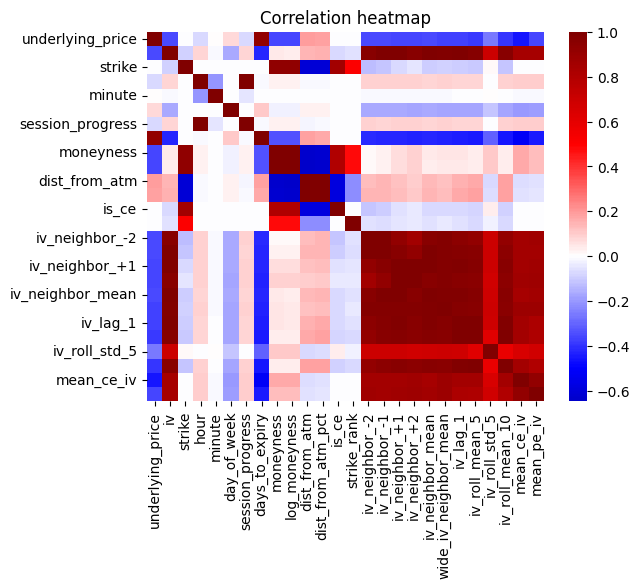

In [53]:
corr_matrix = df_featured.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=False,cmap='seismic',center=0)

plt.title('Correlation heatmap')
plt.show()

In [54]:
corr_matrix['iv'].sort_values(ascending=True)


days_to_expiry          -0.421018
underlying_price        -0.355821
day_of_week             -0.168099
strike                  -0.091660
is_ce                   -0.074008
strike_rank             -0.057512
minute                  -0.014549
log_moneyness            0.041694
moneyness                0.045019
session_progress         0.085943
hour                     0.086565
dist_from_atm            0.143667
dist_from_atm_pct        0.152396
iv_roll_std_5            0.692121
mean_ce_iv               0.844787
mean_pe_iv               0.848839
iv_roll_mean_10          0.963093
iv_neighbor_+2           0.964348
iv_neighbor_-2           0.964348
iv_roll_mean_5           0.973922
wide_iv_neighbor_mean    0.984950
iv_lag_1                 0.987879
iv_neighbor_+1           0.990852
iv_neighbor_-1           0.990852
iv_neighbor_mean         0.996308
iv                       1.000000
Name: iv, dtype: float64

In [55]:
df_featured.to_csv('C:/Users/Ayyan Aftab/Desktop/iv_surface_reconstruct/data/featured_dataset.csv',index=False)